In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [78]:
df=pd.read_csv("AirPassengers.csv",parse_dates=['Month'],index_col="Month")
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [79]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [80]:
df.tail()

,#Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [81]:
df.shape

(144, 1)

In [82]:
df.rename(columns={"#Passengers":"Passengers"}, inplace=True)

In [83]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [9]:
df['Month']=pd.to_datetime(df['Month'])

In [10]:
df.set_index('Month',inplace=True)

In [11]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [12]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [12]:
df=df.asfreq('MS')

<Figure size 1400x200 with 0 Axes>

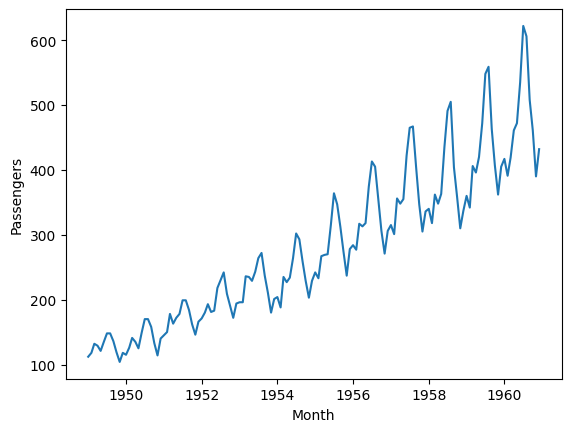

<Figure size 1400x200 with 0 Axes>

In [13]:
plt.plot(df)
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.figure(figsize=(14,2))

In [15]:
df_diff=df[['Passengers']].diff().dropna()

In [16]:
df_diff

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


<Figure size 1400x200 with 0 Axes>

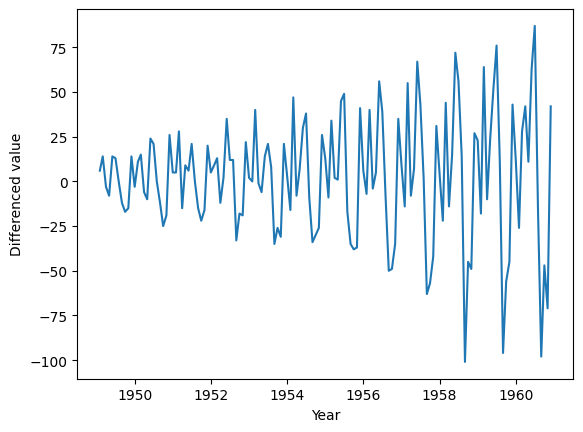

<Figure size 1400x200 with 0 Axes>

In [17]:
plt.plot(df_diff)
plt.xlabel("Year")
plt.ylabel("Differenced value")
plt.figure(figsize=(14,2))

In [20]:
#Seasonal data
monthly_avg=df.groupby(df.index.month)['Passengers'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

<Figure size 1600x200 with 0 Axes>

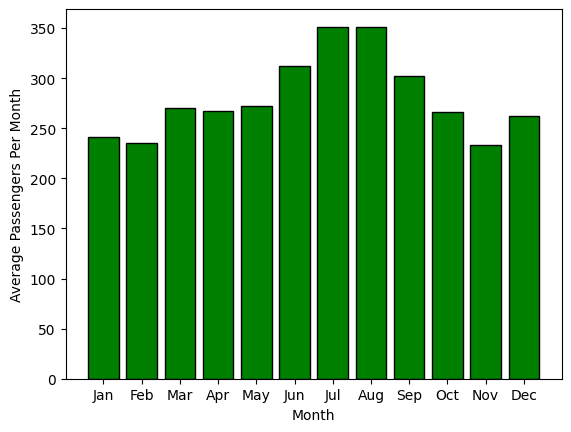

<Figure size 1600x200 with 0 Axes>

In [22]:
plt.bar(month_names,monthly_avg.values,color="green",edgecolor="black")
plt.xlabel("Month")
plt.ylabel("Average Passengers Per Month")
plt.figure(figsize=(16,2))

In [23]:
#Checking Stationarity
from statsmodels.tsa.stattools import adfuller

In [24]:
res=adfuller(df_diff['Passengers'])
print("ADF Statatics:",res[0])
print("P-Value",res[1])

ADF Statatics: -2.8292668241699994
P-Value 0.0542132902838255


In [25]:
df_diff2=df[['Passengers']].diff(2).dropna()


In [26]:
res2=adfuller(df_diff2["Passengers"])
print("ADF-Statatics:",res2[0])
print("P-value",res2[1])

ADF-Statatics: -2.9616951355554244
P-value 0.03862975767698839


In [29]:
# PACF Plot-Partial Auto Corelation Function
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf


Text(0.5, 1.0, 'Second Differnece PACF')

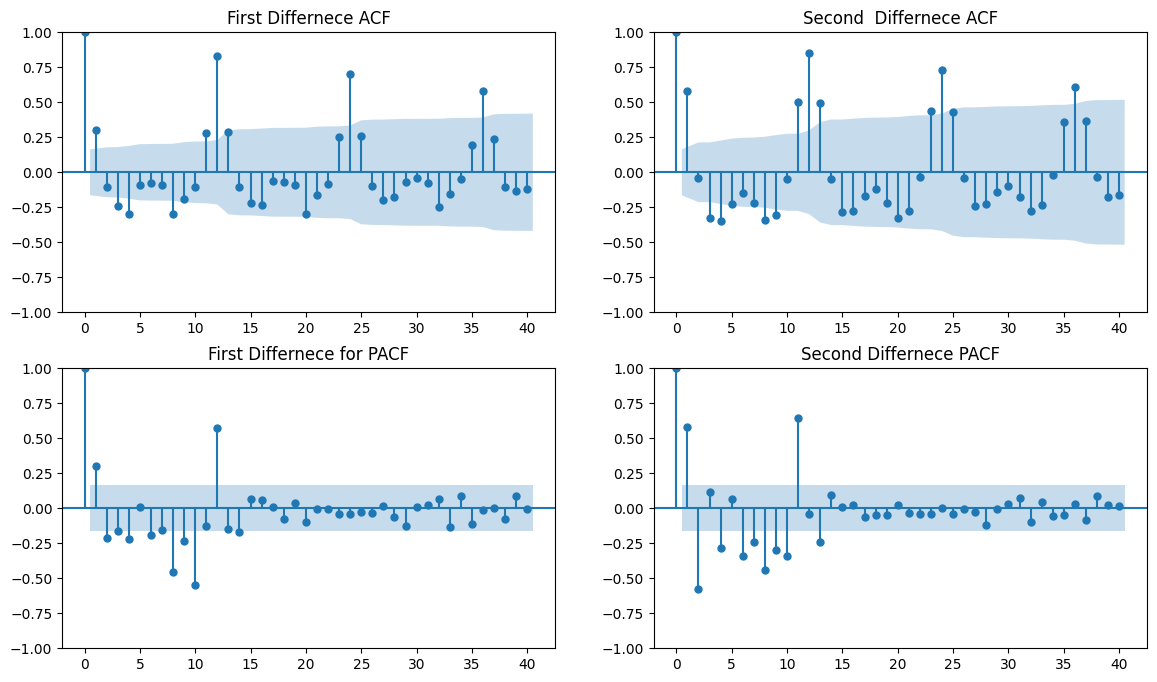

In [30]:
fig,axes=plt.subplots(2,2,figsize=(14,8))
plot_acf(df_diff["Passengers"],lags=40,ax=axes[0,0])
axes[0,0].set_title('First Differnece ACF')
plot_acf(df_diff2["Passengers"],lags=40,ax=axes[0,1])
axes[0,1].set_title('Second  Differnece ACF')
plot_pacf(df_diff["Passengers"],lags=40,ax=axes[1,0])
axes[1,0].set_title('First Differnece for PACF')
plot_pacf(df_diff2["Passengers"],lags=40,ax=axes[1,1])
axes[1,1].set_title('Second Differnece PACF')

In [31]:
# Train Test Split
train_size=len(df)-24
train=df.iloc[:train_size]
test=df.iloc[train_size:]

In [32]:
train.shape

(120, 1)

In [33]:
test.shape

(24, 1)

In [34]:
## Moving Average
window=12
ma_rolling=train["Passengers"].rolling(window=window).mean()
last_ma_value = ma_rolling.iloc[-1]

In [35]:
ma_forecast = pd.Series(
    [last_ma_value] * len(test),
    index=test.index
)

In [36]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
ma_mae  = mean_absolute_error(test['Passengers'], ma_forecast)
ma_rmse = np.sqrt(mean_squared_error(test['Passengers'], ma_forecast))

In [37]:
ma_mae

77.83333333333333

In [33]:
ma_rmse

np.float64(103.21458230308352)

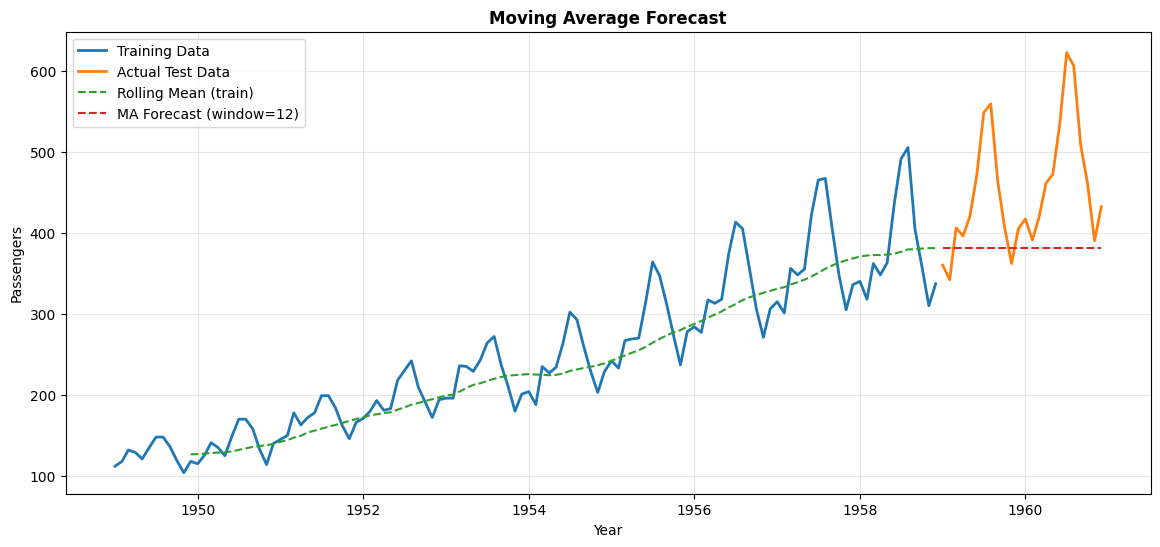

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train['Passengers'], 
        label='Training Data', linewidth=2)

ax.plot(test.index, test['Passengers'],  
        label='Actual Test Data', linewidth=2)

ax.plot(train.index, ma_rolling, 
        label='Rolling Mean (train)', linestyle='--')

ax.plot(test.index, ma_forecast, 
        label='MA Forecast (window=12)', linestyle='--')



ax.set_title('Moving Average Forecast', fontweight='bold')
ax.set_ylabel('Passengers')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, alpha=0.3)


In [39]:
##Arima Model

from statsmodels.tsa.arima.model import ARIMA
arima_model=ARIMA(train["Passengers"],order=(1,2,1))
arima_result=arima_model.fit()             

In [85]:
arima_forecast_obj=arima_result.get_forecast(steps=len(test))
arima_forecast = arima_forecast_obj.predicted_mean

In [38]:
arima_mae  = mean_absolute_error(test['Passengers'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['Passengers'], arima_forecast))

In [39]:
arima_mae

81.70007654444976

In [40]:
arima_rmse

np.float64(106.60706546205958)

In [46]:
#Prediction for 1961
arima_model = ARIMA(df['Passengers'], order=(1,2,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -696.464
Date:                Thu, 26 Feb 2026   AIC                           1398.928
Time:                        10:13:51   BIC                           1407.796
Sample:                    01-01-1949   HQIC                          1402.532
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3130      0.100      3.127      0.002       0.117       0.509
ma.L1         -0.9998      5.966     -0.168      0.867     -12.693      10.693
sigma2      1034.0044   6208.005      0.167      0.8

In [47]:
arima_1961 = arima_fit.forecast(steps=12)

In [48]:
arima_1961

1961-01-01    446.777028
1961-02-01    453.034436
1961-03-01    456.625570
1961-04-01    459.382275
1961-05-01    461.877839
1961-06-01    464.291677
1961-07-01    466.679938
1961-08-01    469.060196
1961-09-01    471.437948
1961-10-01    473.814916
1961-11-01    476.191639
1961-12-01    478.568285
Freq: MS, Name: predicted_mean, dtype: float64

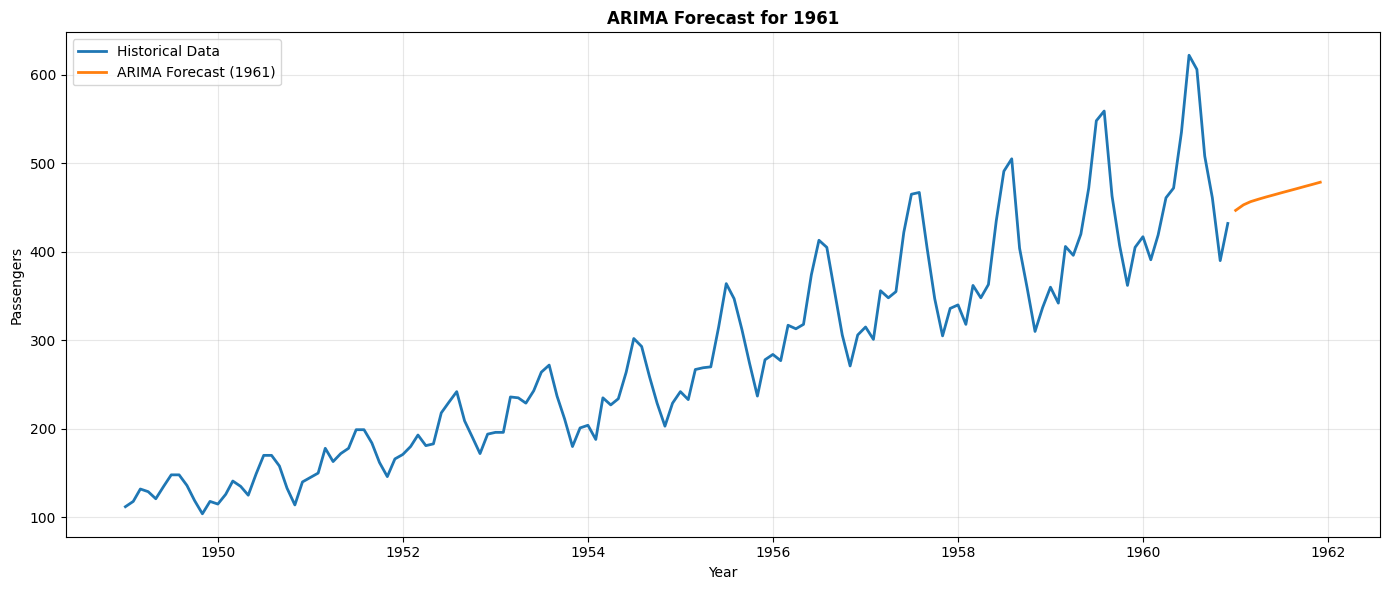

In [50]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Passengers'], 
         label='Historical Data', linewidth=2)

plt.plot(arima_1961.index, arima_1961, 
         label='ARIMA Forecast (1961)', linewidth=2)

plt.title('ARIMA Forecast for 1961', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
#SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima=SARIMAX(train["Passengers"],order=(1,2,1),seasonal_order=(1,2,1,12))
sarimax_fit=model_sarima.fit()
print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 2, 1)x(1, 2, 1, 12)   Log Likelihood                -359.670
Date:                            Thu, 26 Feb 2026   AIC                            729.339
Time:                                    10:15:31   BIC                            742.056
Sample:                                01-01-1949   HQIC                           734.476
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3561      0.091     -3.898      0.000      -0.535      -0.177
ma.L1         -0.9996      6.874   

C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [52]:
sarimax_forecast_obj = sarimax_fit.get_forecast(steps=len(test))

In [53]:
sarimax_forecast = sarimax_forecast_obj.predicted_mean

In [54]:
sarima_mae  = mean_absolute_error(test['Passengers'], sarimax_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['Passengers'], sarimax_forecast))

In [55]:
print("Sarima MAE:",sarima_mae)
print("Sarima RMSE:",sarima_rmse)

Sarima MAE: 76.34654580482277
Sarima RMSE: 84.42401859722847


In [56]:
sarima_model = SARIMAX(
    df['Passengers'],
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -457.315
Date:                            Thu, 26 Feb 2026   AIC                            920.631
Time:                                    10:19:44   BIC                            928.917
Sample:                                01-01-1949   HQIC                           923.995
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3175      0.073     -4.342      0.000      -0.461      -0.174
ma.S.L12      -0.1123      0.097   

In [57]:
sarima_1961 = sarima_fit.forecast(steps=12)

In [58]:
print(sarima_1961)

1961-01-01    447.190092
1961-02-01    422.050204
1961-03-01    453.852860
1961-04-01    489.973736
1961-05-01    502.308080
1961-06-01    564.316164
1961-07-01    649.810259
1961-08-01    636.860591
1961-09-01    539.078212
1961-10-01    491.190950
1961-11-01    423.070498
1961-12-01    464.987472
Freq: MS, Name: predicted_mean, dtype: float64


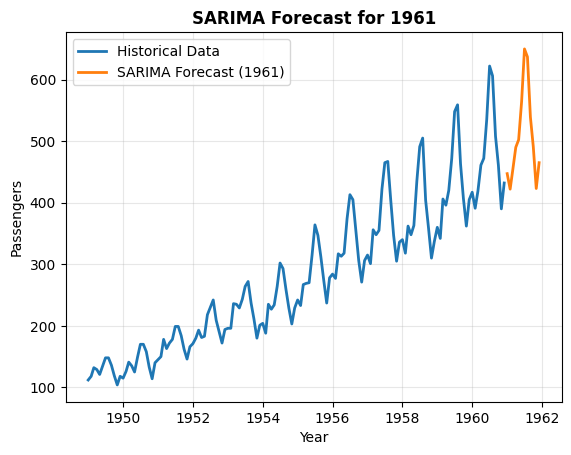

In [59]:
plt.plot(df.index, df['Passengers'], 
         label='Historical Data', linewidth=2)

# SARIMA Forecast
plt.plot(sarima_1961.index, sarima_1961, 
         label='SARIMA Forecast (1961)', linewidth=2)

plt.title('SARIMA Forecast for 1961', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)


In [60]:
##Prophet
train_prophet=train.reset_index().rename(columns={'Month':"ds","Passengers":"y"})
test_prophet=test.reset_index().rename(columns={'Month':"ds","Passengers":"y"})

In [61]:
print(train_prophet.head())

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


In [62]:
from prophet import Prophet

In [63]:
prophet_model=Prophet(
    seasonality_mode='multiplicative',  
    yearly_seasonality=True,
    weekly_seasonality=False,    
    daily_seasonality=False,     
    changepoint_prior_scale=0.05,  
    seasonality_prior_scale=10     
)


In [64]:
prophet_model.fit(train_prophet)

10:20:58 - cmdstanpy - INFO - Chain [1] start processing
10:20:59 - cmdstanpy - INFO - Chain [1] done processing


In [66]:
full_prophet = df.reset_index().rename(
    columns={'Month': 'ds', 'Passengers': 'y'}
)

In [67]:
prophet_model_final = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)


In [68]:
prophet_model_final.fit(full_prophet)

10:23:07 - cmdstanpy - INFO - Chain [1] start processing
10:23:07 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='MS'           # MS = Month Start
)

In [69]:
future_1961 = prophet_model_final.make_future_dataframe(
    periods=12,
    freq='MS'
)

In [87]:
forecast = prophet_model.predict(future)

In [88]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,1949-01-01,115.946722,93.455814,117.034285,115.946722,115.946722,-0.098106,-0.098106,-0.098106,-0.098106,-0.098106,-0.098106,0.0,0.0,0.0,104.571637
1,1949-02-01,117.601266,89.202962,112.431358,117.601266,117.601266,-0.143725,-0.143725,-0.143725,-0.143725,-0.143725,-0.143725,0.0,0.0,0.0,100.698996
2,1949-03-01,119.095692,107.977293,130.084621,119.095692,119.095692,0.004838,0.004838,0.004838,0.004838,0.004838,0.004838,0.0,0.0,0.0,119.671905
3,1949-04-01,120.750236,105.812260,130.005792,120.750236,120.750236,-0.031264,-0.031264,-0.031264,-0.031264,-0.031264,-0.031264,0.0,0.0,0.0,116.975074
4,1949-05-01,122.351407,107.011273,130.975221,122.351407,122.351407,-0.027870,-0.027870,-0.027870,-0.027870,-0.027870,-0.027870,0.0,0.0,0.0,118.941430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,451.515017,540.310962,566.614078,446.765549,456.247332,0.227429,0.227429,0.227429,0.227429,0.227429,0.227429,0.0,0.0,0.0,554.202689
140,1960-09-01,453.942586,464.748473,490.522802,448.779187,459.060498,0.051451,0.051451,0.051451,0.051451,0.051451,0.051451,0.0,0.0,0.0,477.298233
141,1960-10-01,456.291847,402.353733,429.090990,450.676240,461.770984,-0.088804,-0.088804,-0.088804,-0.088804,-0.088804,-0.088804,0.0,0.0,0.0,415.771116
142,1960-11-01,458.719416,355.043928,379.756095,452.673277,464.683556,-0.200175,-0.200175,-0.200175,-0.200175,-0.200175,-0.200175,0.0,0.0,0.0,366.895081


In [70]:
forecast_1961 = prophet_model_final.predict(future_1961)

In [71]:
prophet_1961 = forecast_1961.tail(12)[['ds', 'yhat']]
print(prophet_1961)

            ds        yhat
144 1961-01-01  449.728230
145 1961-02-01  431.006236
146 1961-03-01  491.481950
147 1961-04-01  492.951258
148 1961-05-01  502.174598
149 1961-06-01  577.086066
150 1961-07-01  651.431586
151 1961-08-01  648.132504
152 1961-09-01  551.395445
153 1961-10-01  487.226620
154 1961-11-01  422.963940
155 1961-12-01  471.904393


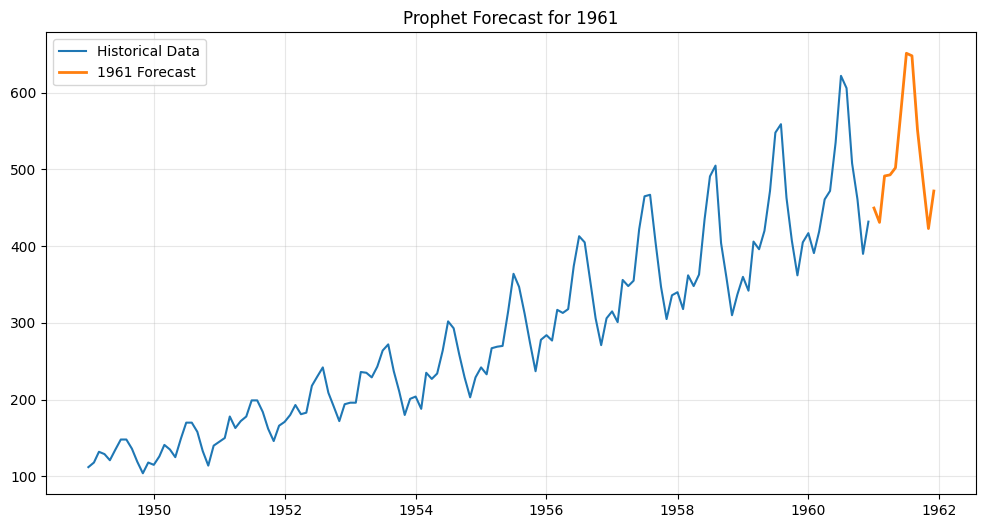

In [72]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Passengers'], label='Historical Data')
plt.plot(prophet_1961['ds'], prophet_1961['yhat'], 
         label='1961 Forecast', linewidth=2)

plt.title('Prophet Forecast for 1961')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [73]:
prophet_1961_series = prophet_1961.set_index('ds')['yhat']

In [74]:
comparison_1961 = pd.DataFrame({
    'ARIMA': arima_1961,
    'SARIMA': sarima_1961,
    'Prophet': prophet_1961_series
})  

In [75]:
comparison_1961

,ARIMA,SARIMA,Prophet
1961-01-01,446.777028,447.190092,449.728230
1961-02-01,453.034436,422.050204,431.006236
1961-03-01,456.625570,453.852860,491.481950
1961-04-01,459.382275,489.973736,492.951258
1961-05-01,461.877839,502.308080,502.174598
1961-06-01,464.291677,564.316164,577.086066
1961-07-01,466.679938,649.810259,651.431586
1961-08-01,469.060196,636.860591,648.132504
1961-09-01,471.437948,539.078212,551.395445
1961-10-01,473.814916,491.190950,487.226620


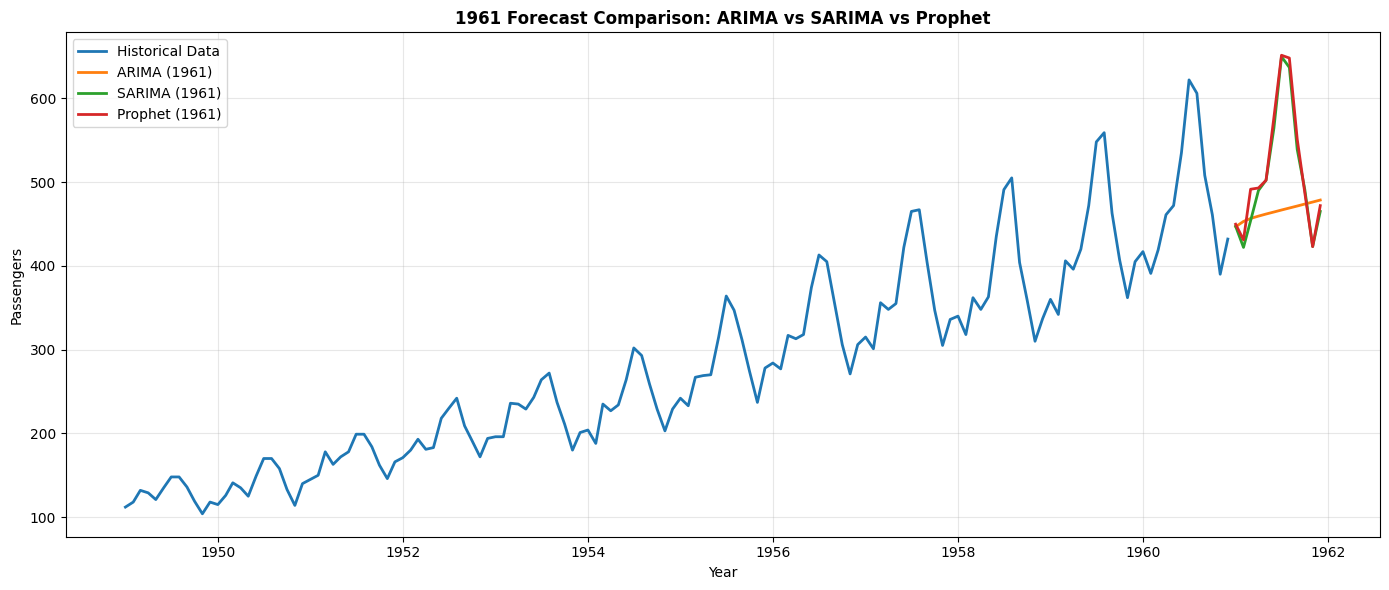

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Historical data
plt.plot(df.index, df['Passengers'], 
         label='Historical Data', linewidth=2)

# Forecasts
plt.plot(comparison_1961.index, comparison_1961['ARIMA'],
         label='ARIMA (1961)', linewidth=2)

plt.plot(comparison_1961.index, comparison_1961['SARIMA'],
         label='SARIMA (1961)', linewidth=2)

plt.plot(comparison_1961.index, comparison_1961['Prophet'],
         label='Prophet (1961)', linewidth=2)

plt.title('1961 Forecast Comparison: ARIMA vs SARIMA vs Prophet',
          fontweight='bold')

plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()